In [13]:
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u
from matplotlib.ticker import ScalarFormatter
from spectrum_component_analyser.spectral_component import spectral_component
from spectrum_component_analyser.mcmc.simulated_spectra import get_simulated_spectra
from spectrum_component_analyser.mcmc.constrained_helper import ConstrainedMCMCHelper
from phoenix_grid_creator.spectral_grid import spectral_grid

from constants import *
from astropy import units as u

from phoenix_grid_creator.spectral_grid import spectral_grid
from spectrum_component_analyser.phoenix_spectrum import phoenix_spectrum
from spectrum_component_analyser.chi_squared_minimisation import ChiHelper, get_chi_r

# both actual global constants
NUMBER_OF_PARAMETERS : int = 4 # weight, t, f, l

fits_file_paths = list(Path(package_path / "raw_phoenix_spectra").rglob("*.fits"))

In [54]:
snrs = np.logspace(-2, 6, 10)
print(snrs)

true_feh = 0.0 * u.dex
true_logg = 4.5 * u.dex

true_components = [
    spectral_component(3800 * u.K, true_feh, true_logg, 0.85),
    spectral_component(3300 * u.K, true_feh, true_logg, 0.15)
]

results = []

resolution = 0.3 * u.nm
observational_wavelengths = np.arange(0.8, 5.5, resolution.to(u.um).value) * u.um
print(observational_wavelengths)
spec_grid = spectral_grid.from_local_raw(fits_file_paths, False, observational_wavelengths)
spec_grid.Wavelengths = spec_grid.Wavelengths.to(u.um)
spec_grid.Fluxes *= u.Jy

for snr in snrs:
    print(f"SNR = {snr}")
    _, _, obs = get_simulated_spectra(spec_grid, true_components, snr=snr)
    
    chi_r = get_chi_r(len(true_components), NUMBER_OF_PARAMETERS, obs, spec_grid)
    
    # should be done by spectral grid class or the mcmchelper classes
    parameter_bounds = [
        (.0, 2.),
        (np.min(spec_grid.T_effs.value), np.max(spec_grid.T_effs.value)),
        (np.min(spec_grid.FeHs.value), np.max(spec_grid.FeHs.value)),
        (np.min(spec_grid.Log_gs.value), np.max(spec_grid.Log_gs.value)),
    ]

    mcmc = ConstrainedMCMCHelper(
        parameter_bounds=parameter_bounds,
        number_of_components=len(true_components),
        observed_spectrum=obs,
        spec_grid=spec_grid,
        n_steps=1500,
        n_walkers=int(2.5 * len(true_components) * NUMBER_OF_PARAMETERS)
    )
    
    sampler, samples = mcmc.run(chi_r)
    results.append(np.percentile(samples, [16, 50, 84], axis=0))

medians = np.array([r[1] for r in results])
lower_err = medians - np.array([r[0] for r in results])
upper_err = np.array([r[2] for r in results]) - medians

[1.00000000e-02 7.74263683e-02 5.99484250e-01 4.64158883e+00
 3.59381366e+01 2.78255940e+02 2.15443469e+03 1.66810054e+04
 1.29154967e+05 1.00000000e+06]
[0.8    0.8003 0.8006 ... 5.4992 5.4995 5.4998] um
[PHOENIX GRID CREATOR] : phoenix wavelength grid found & loaded in
[2300. 2400. 2500. 2600. 2700. 2800. 2900. 3000. 3100. 3200. 3300. 3400.
 3500. 3600. 3700. 3800. 3900. 4000. 4100. 4200. 4300. 4400. 4500.] K


loading in spectra...: 100%|██████████| 2691/2691 [01:57<00:00, 22.91it/s]


SNR = 0.01
[(0.0, 2.0), (np.float64(2300.0), np.float64(4500.0)), (np.float64(-4.0), np.float64(1.0)), (np.float64(0.0), np.float64(6.0))]
[ 6.82051393e-01  3.70955694e+03 -8.99040020e-01  1.92642690e+00
  1.43159471e-02  3.37572627e+03 -2.27408580e+00  1.15971111e+00] 239.95730922026044


Running MCMC...


  0%|          | 0/1500 [00:00<?, ?it/s]/home/bengreen/.cache/pypoetry/virtualenvs/stellar-heterogeneity-modelling-HvrJltTr-py3.11/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 1500/1500 [00:32<00:00, 46.03it/s]


...

100%|██████████| 1500/1500 [00:48<00:00, 30.85it/s]


MCMC Median Shared Fe/H: -0.01
MCMC Median Shared logg: 4.49
Mean acceptance fraction: 0.407
SNR = 1000000.0
[(0.0, 2.0), (np.float64(2300.0), np.float64(4500.0)), (np.float64(-4.0), np.float64(1.0)), (np.float64(0.0), np.float64(6.0))]
[ 6.77851189e-01  3.99885744e+03 -1.84468171e-01  3.75568305e-01
  3.33480107e-01  3.89605718e+03 -2.49162158e+00  1.83291754e+00] 0.007031948881966591
[ 9.84578273e-01  3.59919104e+03 -1.22753514e+00  3.73168116e+00
  4.14255166e-02  3.81832390e+03 -3.98815566e+00  2.02182629e+00] 0.006811216776907002
[ 9.84578273e-01  3.59919104e+03 -1.22753514e+00  3.73168116e+00
  4.14255166e-02  3.81832390e+03 -3.98815566e+00  2.02182629e+00] 0.006736521461660649
[ 2.84216973e-01  3.75799499e+03 -1.48709036e-01  1.56687717e+00
  6.98838668e-01  3.72910632e+03 -4.51797325e-02  5.84925929e+00] 0.0057418279829868114
[ 2.84216973e-01  3.75799499e+03 -1.48709036e-01  1.56687717e+00
  6.98838668e-01  3.72910632e+03 -4.51797325e-02  5.84925929e+00] 0.004982504570764299
[ 

Running MCMC...


100%|██████████| 1500/1500 [00:48<00:00, 31.07it/s]

MCMC Median Shared Fe/H: -0.02
MCMC Median Shared logg: 4.49
Mean acceptance fraction: 0.386


In [55]:
import corner
import emcee


def plot_corner(mcmc : ConstrainedMCMCHelper, sampler : emcee.EnsembleSampler, samples : np.ndarray, true_components : list[spectral_component]):
    labels = []
    for i in range(mcmc.number_of_components):
        labels += [f"$f_{i+1}$", f"$T_{i+1}$ [K]"]
    labels += ["[Fe/H] [dex]", r"$\log g$ [dex]"]

    main_fill_color = "#FF8B00"
    quantile_line_color = "#AC8DD9"

    # fig, axes = plt.subplots(samples.shape[1], samples.shape[1], figsize=(16, 16))
    
    fontsize = 12
    plt.rc('xtick', labelsize=fontsize - 2)
    plt.rc('ytick', labelsize=fontsize - 2)

    true_params = []
    for c in true_components:
        true_params += [c.Weight, c.T_eff.value]
    true_params += [true_feh.value, true_logg.value]
    print(true_feh)
    print(true_logg)
    
    true_params = np.array(true_params, dtype=float)

    truth_color = "black"

    fig = corner.corner(
        samples,
        truths=true_params,
        truth_color=truth_color,
        # fig=fig,
        labels=labels, 
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True,
        # --- Neatness Settings ---
        color=main_fill_color,
        plot_datapoints=False,         # Removes the scatter points
        plot_density=False,            # Removes the low-res "square" histogram
        fill_contours=True,         # Keeps it looking minimal
        levels=(1 - np.exp(-0.5 * np.arange(1, 4)**2)), # Standard 1, 2, 3 sigma
        contour_kwargs={"colors": [main_fill_color], "linewidths": 1.0},
        hist_kwargs={
            "color": "black",             # This sets the 'edgecolor' when histtype='step'
            "fill": True,                 # Enables the fill
            "facecolor": main_fill_color, # The color inside the histograms
            "edgecolor": "black",         # The outline color
            "linewidth": 1.5,
            "alpha": 0.5                  # Slight transparency often looks cleaner
        },
        title_kwargs={"fontsize": fontsize},
        label_kwargs={"fontsize": fontsize},     
        )
    
    axes = np.array(fig.axes).reshape((samples.shape[1], samples.shape[1]))

    for i in range(samples.shape[1]):
        ax = axes[i, i] # Target the 1D histograms on the diagonal

        current_title = ax.get_title()
        if "T_" in labels[i]:
            value = current_title.split("=")[1]
            ax.set_title(r"$T_\text{eff}$ =" + f"{value} K", fontsize=fontsize)
        elif "Fe/H" in labels[i]:
            value = current_title.split("=")[1]
            ax.set_title(r"[Fe/H] =" + f"{value} dex", fontsize=fontsize)
        elif "log" in labels[i]:
            value = current_title.split("=")[1]
            ax.set_title(r"$\log g$ =" + f"{value} dex", fontsize=fontsize)
        
        # Corner usually plots quantile lines as 'Line2D' objects
        idx = 0
        for line in ax.get_lines():
            if line.get_color() == truth_color:
                continue
            if (idx == 1):
                line.set_linestyle("-")
            # only count the lines that aren't truth-lines
            idx += 1

            # line.set_color("#705CC8B0")
            # line.set_linestyle("--") # Optional: make them dashed
            # line.set_linewidth(2)     # Optional: make them thicker
    
    for ax in fig.axes:
        for line in ax.get_lines():
            if line.get_color() == truth_color:
                line.set_linewidth(1)
                line.set_markersize(5)
                line.set_zorder(10)

    plt.rcParams['xtick.direction'] = 'in'
    plt.rcParams['ytick.direction'] = 'in'
    # Optional: makes ticks appear on all sides
    plt.rcParams['xtick.top'] = True
    plt.rcParams['ytick.right'] = True

    # fig.suptitle("Posterior distributions for a simulated M dwarf", fontsize=20)
    fig.subplots_adjust(top=0.93)
    plt.show()

    # caterpillar
    fig, axes = plt.subplots(mcmc.ndim, figsize=(10, 7), sharex=True)
    chain = sampler.get_chain()
    for i in range(mcmc.ndim):
        ax = axes[i]
        ax.plot(chain[:, :, i], "k", alpha=0.3)
        ax.set_xlim(0, len(chain))
        ax.set_ylabel(labels[i])
        ax.yaxis.set_label_coords(-0.1, 0.5)

    axes[-1].set_xlabel("Step number")
    # plt.tight_layout()
    plt.show()

0.0 dex
4.5 dex


loading in spectra...:   4%|▍         | 116/2691 [12:24<4:35:20,  6.42s/it]


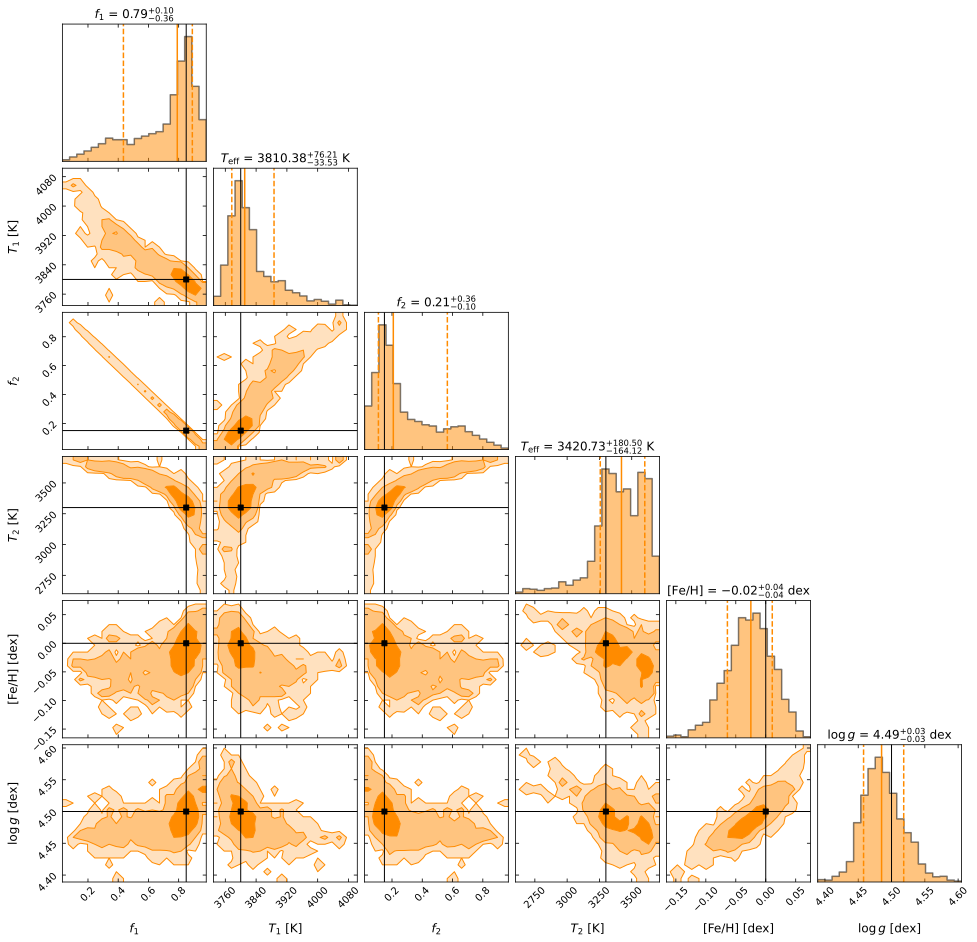

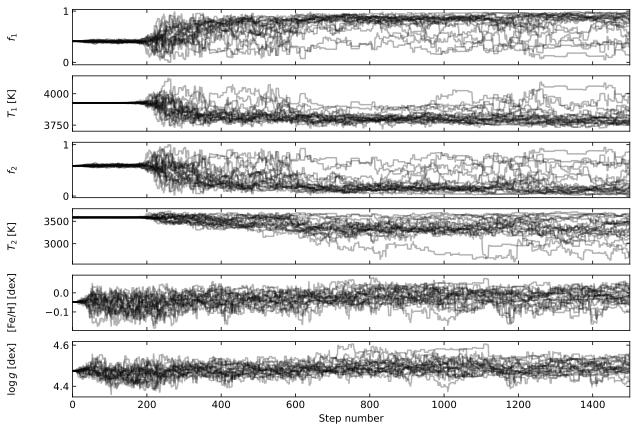

In [ ]:
plot_corner(mcmc, sampler, samples, true_components)

%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

In [59]:
print(medians)

[[ 4.77031381e-01  3.92667107e+03  3.62531376e-01  3.38061806e+03
  -8.74713402e-01  1.58405940e+00]
 [ 7.10111284e-01  4.07967020e+03  3.90510682e-01  3.64516897e+03
   8.54955142e-01  5.60735853e+00]
 [ 6.67987784e-01  4.07926464e+03  3.25079747e-01  3.78794527e+03
  -5.44319913e-01  4.60218053e+00]
 [ 3.40143170e-01  3.75653422e+03  6.58366990e-01  3.69170481e+03
  -2.08949046e-01  4.47212615e+00]
 [ 6.52483279e-01  3.81607817e+03  3.48484551e-01  3.57930441e+03
  -7.93493874e-02  4.45320467e+00]
 [ 8.52080723e-01  3.80069437e+03  1.48119841e-01  3.31104625e+03
  -1.36610975e-02  4.49337521e+00]
 [ 7.18127726e-01  3.82674815e+03  2.81841250e-01  3.48716726e+03
  -3.42488838e-02  4.47882513e+00]
 [ 8.63177198e-01  3.79410617e+03  1.36878252e-01  3.28452478e+03
  -1.14334369e-02  4.49542051e+00]
 [ 8.19365215e-01  3.80336725e+03  1.81351663e-01  3.37593274e+03
  -1.49510154e-02  4.49060449e+00]
 [ 7.90916472e-01  3.81038088e+03  2.08667930e-01  3.42072532e+03
  -2.48275027e-02  4.4850

1000000.0
1000000.0
0.3 nm
[1.00000000e-02 7.74263683e-02 5.99484250e-01 4.64158883e+00
 3.59381366e+01 2.78255940e+02 2.15443469e+03 1.66810054e+04
 1.29154967e+05 1.00000000e+06]


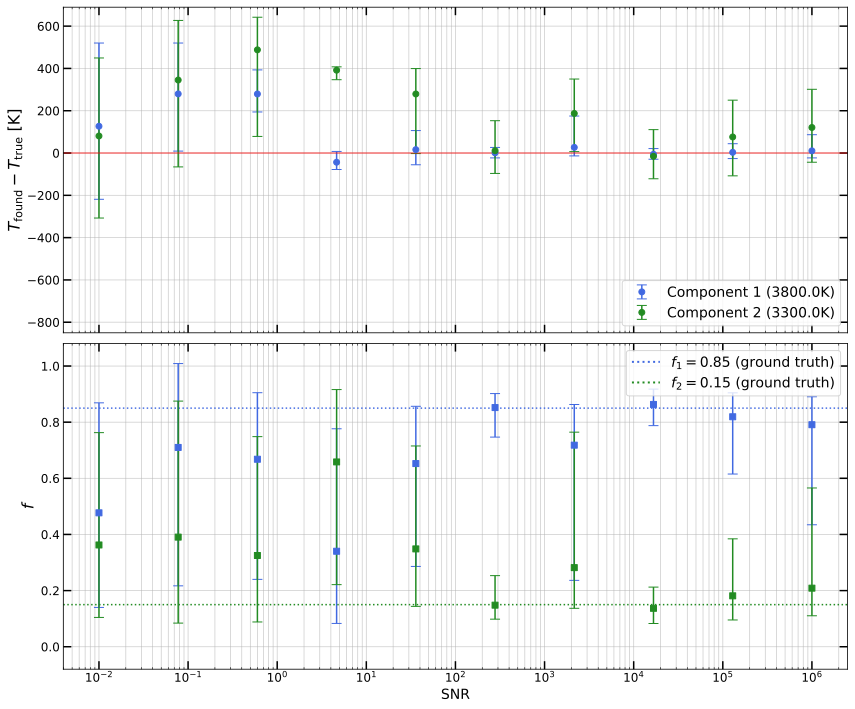

In [ ]:
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
fontsize=14
comp_colors = ['royalblue', 'forestgreen']

for i in range(len(true_components)):
    t_true = true_components[i].T_eff.value
    w_true = true_components[i].Weight
    
    w_idx = i * 2
    t_idx = i * 2 + 1

    print(snr)
    
    ax1.errorbar(snrs, medians[:, t_idx] - t_true, 
                 yerr=[lower_err[:, t_idx], upper_err[:, t_idx]],
                 fmt='o', color=comp_colors[i], capsize=5,
                 label=f'Component {i+1} ({t_true}K)')
    
    ax2.errorbar(snrs, medians[:, w_idx], 
                 yerr=[lower_err[:, w_idx], upper_err[:, w_idx]],
                 fmt='s', color=comp_colors[i], capsize=5)
                #  label=f'Component {i+1} (Truth: {w_true})')
    ax2.axhline(w_true, color=comp_colors[i], alpha=0.99, linestyle=':', label="$f_"+f"{i+1}"+f"={w_true}$ (ground truth)")

# real life resolutions
# ax1.axvline(2.2*u.um/150)
# ax1.axvline(0.8*u.um/150)
# ax1.axvline(5*u.um/1000)
# ax1.axvline(2*u.um/3500)
# ax1.axvline(0.8*u.um/150)
print(resolution)
print(snrs)

ax1.axhline(0, color='red', alpha=0.5)
ax1.set_ylabel(r"$T_{\mathrm{found}} - T_{\mathrm{true}}$ [K]",fontsize=fontsize+2)
ax1.legend(fontsize=fontsize, loc='lower right')
ax1.set_ylim(-850)

ax2.set_ylabel("$f$", fontsize=fontsize+2)
ax2.set_ylim(-0.08, 1.08)
ax2.set_xlabel(r"SNR", fontsize=fontsize)
ax2.set_xscale('log')
# ax2.xaxis.set_major_formatter(ScalarFormatter())
leg = ax2.legend(fontsize=fontsize, loc='upper right')
for line in leg.get_lines():
    line.set_linewidth(2.0)
for ax in [ax1, ax2]:
    ax.grid(which='both', alpha=0.6)
    ax.invert_xaxis()
    ax.tick_params(axis='both', which='major', labelsize=12, length=8, width=1.5)

plt.tight_layout()
plt.savefig("snr_variation_3.svg", format="svg", bbox_inches='tight')
plt.show()